<a href="https://colab.research.google.com/github/dimitarpg13/agentic_architectures_and_design_patterns/blob/main/notebooks/task_driven_load_distribution/web_search_example_via_task_queue.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔄 Task-Driven Load Distribution Pattern for Multi-Agent Workflows

This notebook demonstrates the **Task-Driven Load Distribution** design pattern using LangGraph, featuring:
- **Orchestrator Agent**: Creates tasks and pushes them to a shared task queue
- **Worker Agents**: Pop tasks from the queue and execute web searches
- **Task Queue**: Shared queue for producer-consumer communication

## Architecture

```
┌──────────────────────────────────────────────────────────────────────────┐
│                    TASK-DRIVEN LOAD DISTRIBUTION                         │
├──────────────────────────────────────────────────────────────────────────┤
│                                                                          │
│  ┌─────────────────┐                                                     │
│  │   User Query    │                                                     │
│  └────────┬────────┘                                                     │
│           │                                                              │
│           ▼                                                              │
│  ┌─────────────────┐        push         ┌─────────────────┐            │
│  │  ORCHESTRATOR   │ ──────────────────► │   TASK QUEUE    │            │
│  │     AGENT       │                     │                 │            │
│  │                 │                     │  [Task 1]       │            │
│  │ • Analyze query │                     │  [Task 2]       │            │
│  │ • Create tasks  │                     │  [Task 3]       │            │
│  │ • Push to queue │                     │  [...]          │            │
│  └─────────────────┘                     └────────┬────────┘            │
│                                                   │                      │
│                                      pop          │                      │
│                    ┌──────────────────────────────┼───────────────┐      │
│                    │                              │               │      │
│                    ▼                              ▼               ▼      │
│           ┌─────────────┐              ┌─────────────┐    ┌─────────────┐│
│           │  Worker 1   │              │  Worker 2   │    │  Worker 3   ││
│           │  (Search)   │              │  (Search)   │    │  (Search)   ││
│           └──────┬──────┘              └──────┬──────┘    └──────┬──────┘│
│                  │                            │                  │       │
│                  └────────────────────────────┼──────────────────┘       │
│                                               ▼                          │
│                                    ┌─────────────────┐                   │
│                                    │ Result Aggregator│                  │
│                                    │   (Synthesizer)  │                  │
│                                    └────────┬─────────┘                  │
│                                             │                            │
│                                             ▼                            │
│                                    ┌─────────────────┐                   │
│                                    │  Final Report   │                   │
│                                    └─────────────────┘                   │
└──────────────────────────────────────────────────────────────────────────┘
```

## Key Features
- **Producer-Consumer Pattern**: Orchestrator produces tasks, workers consume
- **Shared Task Queue**: Thread-safe queue for task distribution
- **Parallel Processing**: Multiple workers process tasks concurrently
- **Tavily Web Search**: Real-time information retrieval

## 1. Environment Setup

In [1]:
# Install required packages
%pip install -q langchain langchain-openai langchain-anthropic langgraph tavily-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 405.9/405.9 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 496.3/496.3 kB 15.0 MB/s eta 0:00:00


In [2]:
import os
import asyncio
from queue import Queue
from threading import Lock
from typing import List, Dict, Any, Optional, Literal, TypedDict
from dataclasses import dataclass, field
from datetime import datetime
from enum import Enum
import uuid

# LangChain imports
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# LangGraph imports
from langgraph.graph import StateGraph, END, START

# Web search
from tavily import TavilyClient

print("✅ All imports successful!")

✅ All imports successful!


## 2. API Configuration

In [3]:
from getpass import getpass

# Choose your LLM provider
LLM_PROVIDER = "openai"  # Options: "openai", "anthropic"

# Set API keys
if LLM_PROVIDER == "openai" and "OPENAI_API_KEY" not in os.environ:
    os.environ["OPENAI_API_KEY"] = getpass("Enter your OpenAI API key: ")
elif LLM_PROVIDER == "anthropic" and "ANTHROPIC_API_KEY" not in os.environ:
    os.environ["ANTHROPIC_API_KEY"] = getpass("Enter your Anthropic API key: ")

if "TAVILY_API_KEY" not in os.environ:
    os.environ["TAVILY_API_KEY"] = getpass("Enter your Tavily API key: ")

print(f"✅ Configured for {LLM_PROVIDER.upper()} with Tavily web search")

Enter your OpenAI API key: ··········
Enter your Tavily API key: ··········
✅ Configured for OPENAI with Tavily web search


## 3. Initialize LLM and Tavily

In [4]:
def get_llm(provider: str = "openai", temperature: float = 0.7):
    """Initialize the LLM based on the selected provider."""
    if provider == "openai":
        from langchain_openai import ChatOpenAI
        return ChatOpenAI(model="gpt-4o", temperature=temperature)
    elif provider == "anthropic":
        from langchain_anthropic import ChatAnthropic
        return ChatAnthropic(model="claude-sonnet-4-20250514", temperature=temperature)
    else:
        raise ValueError(f"Unknown provider: {provider}")

# Initialize LLM
llm = get_llm(LLM_PROVIDER)

# Initialize Tavily client
tavily_client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])

print(f"✅ LLM initialized: {LLM_PROVIDER}")
print("✅ Tavily client initialized")

✅ LLM initialized: openai
✅ Tavily client initialized


## 4. Define Task Queue and Data Structures

The task queue is the central component that enables the producer-consumer pattern between the orchestrator and workers.

In [5]:
class TaskStatus(str, Enum):
    """Status of a task."""
    PENDING = "pending"
    IN_PROGRESS = "in_progress"
    COMPLETED = "completed"
    FAILED = "failed"


@dataclass
class SearchTask:
    """Represents a single search task."""
    task_id: str
    query: str
    priority: int = 1  # Higher = more important
    status: TaskStatus = TaskStatus.PENDING
    assigned_worker: Optional[str] = None
    result: Optional[str] = None
    error: Optional[str] = None
    created_at: str = field(default_factory=lambda: datetime.now().isoformat())


class TaskQueue:
    """Thread-safe task queue for producer-consumer pattern.

    The Orchestrator pushes tasks to this queue.
    Workers pop tasks from this queue.
    """

    def __init__(self):
        self._queue: Queue = Queue()
        self._lock = Lock()
        self._all_tasks: Dict[str, SearchTask] = {}
        self._results: List[Dict[str, Any]] = []

    def push(self, task: SearchTask) -> None:
        """Push a task to the queue (used by Orchestrator)."""
        with self._lock:
            self._all_tasks[task.task_id] = task
            self._queue.put(task)
            print(f"   📥 Task pushed: {task.task_id} - {task.query[:40]}...")

    def pop(self) -> Optional[SearchTask]:
        """Pop a task from the queue (used by Workers)."""
        try:
            task = self._queue.get_nowait()
            return task
        except Exception:
            return None

    def is_empty(self) -> bool:
        """Check if the queue is empty."""
        return self._queue.empty()

    def size(self) -> int:
        """Get the number of tasks in the queue."""
        return self._queue.qsize()

    def add_result(self, task_id: str, worker_id: str, result: str) -> None:
        """Add a result for a completed task."""
        with self._lock:
            if task_id in self._all_tasks:
                self._all_tasks[task_id].status = TaskStatus.COMPLETED
                self._all_tasks[task_id].result = result
                self._all_tasks[task_id].assigned_worker = worker_id
            self._results.append({
                "task_id": task_id,
                "worker_id": worker_id,
                "query": self._all_tasks[task_id].query if task_id in self._all_tasks else "",
                "result": result
            })

    def mark_failed(self, task_id: str, error: str) -> None:
        """Mark a task as failed."""
        with self._lock:
            if task_id in self._all_tasks:
                self._all_tasks[task_id].status = TaskStatus.FAILED
                self._all_tasks[task_id].error = error

    def get_all_results(self) -> List[Dict[str, Any]]:
        """Get all completed results."""
        return self._results.copy()

    def get_stats(self) -> Dict[str, int]:
        """Get queue statistics."""
        with self._lock:
            stats = {
                "total": len(self._all_tasks),
                "pending": self._queue.qsize(),
                "completed": sum(1 for t in self._all_tasks.values() if t.status == TaskStatus.COMPLETED),
                "failed": sum(1 for t in self._all_tasks.values() if t.status == TaskStatus.FAILED),
            }
            return stats


# Create global task queue
task_queue = TaskQueue()
print("✅ Task queue created")

✅ Task queue created


## 5. Define Workflow State

In [6]:
class WorkflowState(TypedDict):
    """State for the load distribution workflow.

    Attributes:
        user_query: The original user query
        task_queue: Reference to the shared task queue
        num_workers: Number of worker agents
        worker_results: Results collected from workers
        final_report: Synthesized final report
        phase: Current phase of the workflow
    """
    user_query: str
    num_workers: int
    worker_results: List[Dict[str, Any]]
    final_report: str
    phase: str
    tasks_created: int
    tasks_completed: int


print("✅ Workflow state defined")

✅ Workflow state defined


## 6. Web Search Function

In [7]:
def perform_web_search(query: str, max_results: int = 5) -> str:
    """Perform a web search using Tavily API.

    Args:
        query: The search query
        max_results: Maximum number of results

    Returns:
        Formatted search results
    """
    try:
        response = tavily_client.search(
            query=query,
            search_depth="advanced",
            max_results=max_results,
            include_answer=True,
        )

        results = []

        if response.get("answer"):
            results.append(f"**Summary:** {response['answer']}\n")

        results.append("**Sources:**")
        for i, r in enumerate(response.get("results", []), 1):
            title = r.get("title", "No title")
            url = r.get("url", "")
            content = r.get("content", "")[:250]
            results.append(f"{i}. **{title}**\n   {url}\n   {content}...\n")

        return "\n".join(results)

    except Exception as e:
        return f"Search error: {str(e)}"


# Test search
print("Testing Tavily search...")
test_result = perform_web_search("LangGraph multi-agent", max_results=2)
print(f"✅ Search working. Preview:\n{test_result[:300]}...")

Testing Tavily search...
✅ Search working. Preview:
**Summary:** LangGraph is a framework for building stateful, multi-agent applications using language models. It allows agents to collaborate and maintain conversation state. It is simpler than full platforms like Google’s ADK.

**Sources:**
1. **Building Multi-Agent Systems with LangGraph: A Step-by...


## 7. Define Agent Prompts

In [8]:
ORCHESTRATOR_PROMPT = """You are a task orchestrator. Your job is to analyze a user query and
decompose it into specific, independent search tasks that can be executed in parallel.

User Query: {query}

Break this down into 3-5 specific search queries. Each query should:
- Focus on a distinct aspect of the topic
- Be specific enough to get relevant search results
- Be independent (not dependent on results from other queries)

Return ONLY a numbered list of search queries, one per line:
1. First specific search query
2. Second specific search query
3. Third specific search query
...
"""

SYNTHESIZER_PROMPT = """You are an expert at synthesizing research findings.

Original Query: {query}

Search Results from Multiple Workers:
{results}

Create a comprehensive report with:
1. **Executive Summary** - Key findings in 2-3 sentences
2. **Main Findings** - Organized by topic
3. **Key Insights** - Important takeaways
4. **Conclusion** - Summary and recommendations

Be specific and cite information from the search results.
"""

print("✅ Prompts defined")

✅ Prompts defined


## 8. Define Workflow Nodes

### Orchestrator Agent
The orchestrator creates tasks and pushes them to the queue.

In [9]:
def orchestrator_agent(state: WorkflowState) -> WorkflowState:
    """Orchestrator agent that creates tasks and pushes them to the queue.

    This agent:
    1. Analyzes the user query
    2. Decomposes it into independent search tasks
    3. Pushes each task to the shared task queue
    """
    print("\n" + "="*60)
    print("🎯 ORCHESTRATOR AGENT: Creating and pushing tasks")
    print("="*60)

    query = state["user_query"]

    # Use LLM to decompose the query into tasks
    prompt = ChatPromptTemplate.from_template(ORCHESTRATOR_PROMPT)
    chain = prompt | llm | StrOutputParser()
    decomposed = chain.invoke({"query": query})

    print(f"\n📋 Decomposed query into tasks:")

    # Parse and create tasks
    lines = [line.strip() for line in decomposed.strip().split("\n") if line.strip()]
    tasks_created = 0

    for line in lines:
        # Remove numbering
        if line[0].isdigit() and "." in line[:3]:
            query_text = line.split(".", 1)[1].strip()
        else:
            query_text = line

        if query_text:
            task = SearchTask(
                task_id=str(uuid.uuid4())[:8],
                query=query_text,
                priority=1
            )
            task_queue.push(task)
            tasks_created += 1

    print(f"\n✅ Orchestrator pushed {tasks_created} tasks to queue")
    print(f"   Queue size: {task_queue.size()}")

    return {
        **state,
        "phase": "workers",
        "tasks_created": tasks_created,
    }


print("✅ Orchestrator agent defined")

✅ Orchestrator agent defined


### Worker Agents
Workers pop tasks from the queue and execute web searches.

In [10]:
def worker_agent(state: WorkflowState, worker_id: str) -> Dict[str, Any]:
    """Worker agent that pops a task from the queue and executes it.

    Args:
        state: Current workflow state
        worker_id: Unique identifier for this worker

    Returns:
        Updated state with worker results
    """
    # Pop a task from the queue
    task = task_queue.pop()

    if task is None:
        print(f"   🤖 {worker_id}: No tasks available")
        return {"result": None, "worker_id": worker_id}

    print(f"   🤖 {worker_id}: Popped task {task.task_id}")
    print(f"      Query: {task.query[:50]}...")

    task.status = TaskStatus.IN_PROGRESS
    task.assigned_worker = worker_id

    try:
        # Execute web search
        result = perform_web_search(task.query)

        # Store result
        task_queue.add_result(task.task_id, worker_id, result)

        print(f"      ✅ Completed")
        return {
            "task_id": task.task_id,
            "query": task.query,
            "result": result,
            "worker_id": worker_id,
            "status": "completed"
        }

    except Exception as e:
        task_queue.mark_failed(task.task_id, str(e))
        print(f"      ❌ Failed: {str(e)}")
        return {
            "task_id": task.task_id,
            "query": task.query,
            "error": str(e),
            "worker_id": worker_id,
            "status": "failed"
        }


def workers_execute(state: WorkflowState) -> WorkflowState:
    """Execute all workers to process tasks from the queue."""
    print("\n" + "="*60)
    print("👷 WORKERS: Popping and executing tasks from queue")
    print("="*60)

    num_workers = state["num_workers"]
    worker_results = state.get("worker_results", [])
    tasks_completed = state.get("tasks_completed", 0)

    # Each worker pops one task from the queue
    for i in range(num_workers):
        worker_id = f"worker_{i+1}"

        if task_queue.is_empty():
            print(f"\n   📭 Queue empty, no more tasks for workers")
            break

        result = worker_agent(state, worker_id)
        if result.get("result") or result.get("error"):
            worker_results.append(result)
            if result.get("status") == "completed":
                tasks_completed += 1

    stats = task_queue.get_stats()
    print(f"\n📊 Queue Stats: {stats}")

    return {
        **state,
        "worker_results": worker_results,
        "tasks_completed": tasks_completed,
        "phase": "check" if not task_queue.is_empty() else "aggregate",
    }


print("✅ Worker agents defined")

✅ Worker agents defined


### Result Aggregator
Synthesizes all worker results into a final report.

In [11]:
def result_aggregator(state: WorkflowState) -> WorkflowState:
    """Aggregate and synthesize results from all workers."""
    print("\n" + "="*60)
    print("📊 RESULT AGGREGATOR: Synthesizing findings")
    print("="*60)

    worker_results = state["worker_results"]
    user_query = state["user_query"]

    # Format results for synthesis
    formatted_results = []
    for r in worker_results:
        if r.get("result"):
            formatted_results.append(
                f"### Search Query: {r['query']}\n"
                f"**Worker:** {r['worker_id']}\n\n"
                f"{r['result']}\n\n"
                f"---\n"
            )

    all_results = "\n".join(formatted_results)

    # Use LLM to synthesize
    prompt = ChatPromptTemplate.from_template(SYNTHESIZER_PROMPT)
    chain = prompt | llm | StrOutputParser()

    final_report = chain.invoke({
        "query": user_query,
        "results": all_results,
    })

    print(f"\n✅ Report synthesized ({len(final_report)} characters)")

    return {
        **state,
        "final_report": final_report,
        "phase": "complete",
    }


print("✅ Result aggregator defined")

✅ Result aggregator defined


## 9. Routing Logic

In [12]:
def should_continue_processing(state: WorkflowState) -> Literal["workers", "aggregate"]:
    """Determine if more tasks need processing or ready to aggregate."""

    if task_queue.is_empty():
        print("\n✅ All tasks processed, proceeding to aggregation...")
        return "aggregate"
    else:
        remaining = task_queue.size()
        print(f"\n🔄 {remaining} tasks remaining in queue, continuing...")
        return "workers"


print("✅ Routing logic defined")

✅ Routing logic defined


## 10. Build the LangGraph Workflow

In [13]:
def build_load_distribution_workflow():
    """Build the task-driven load distribution workflow."""

    workflow = StateGraph(WorkflowState)

    # Add nodes
    workflow.add_node("orchestrator", orchestrator_agent)
    workflow.add_node("workers", workers_execute)
    workflow.add_node("aggregate", result_aggregator)

    # Define edges
    # Start -> Orchestrator (creates tasks, pushes to queue)
    workflow.add_edge(START, "orchestrator")

    # Orchestrator -> Workers (workers pop from queue)
    workflow.add_edge("orchestrator", "workers")

    # Workers -> Check if more tasks -> Workers or Aggregate
    workflow.add_conditional_edges(
        "workers",
        should_continue_processing,
        {
            "workers": "workers",
            "aggregate": "aggregate",
        }
    )

    # Aggregate -> End
    workflow.add_edge("aggregate", END)

    return workflow.compile()


# Build the workflow
app = build_load_distribution_workflow()

print("✅ Workflow built successfully!")
print("\nWorkflow: START → Orchestrator → Workers ⟷ (loop) → Aggregate → END")

✅ Workflow built successfully!

Workflow: START → Orchestrator → Workers ⟷ (loop) → Aggregate → END


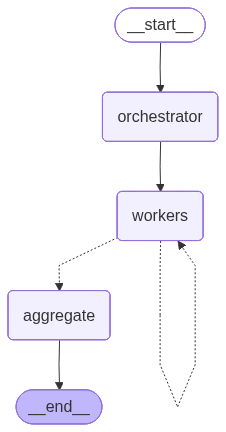

In [14]:
# Visualize the workflow (optional)
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print("Graph visualization:")
    print("""
    ┌───────────────┐
    │     START     │
    └───────┬───────┘
            │
            ▼
    ┌───────────────┐
    │  Orchestrator │ ──► Creates tasks, pushes to queue
    └───────┬───────┘
            │
            ▼
    ┌───────────────┐
    │    Workers    │◄─┐ ──► Pop tasks from queue, execute
    └───────┬───────┘  │
            │          │
            ▼          │
      [Queue empty?]───┘
            │ Yes
            ▼
    ┌───────────────┐
    │   Aggregate   │ ──► Synthesize results
    └───────┬───────┘
            │
            ▼
    ┌───────────────┐
    │      END      │
    └───────────────┘
    """)

## 11. Run the System

In [15]:
def run_distributed_search(query: str, num_workers: int = 3):
    """Run a distributed search using the task-driven load distribution pattern.

    Args:
        query: The research query
        num_workers: Number of worker agents

    Returns:
        Final state with results
    """
    # Reset the task queue for a fresh run
    global task_queue
    task_queue = TaskQueue()

    print("\n" + "="*80)
    print("🚀 TASK-DRIVEN LOAD DISTRIBUTION SYSTEM")
    print("="*80)
    print(f"\n📌 Query: {query}")
    print(f"👷 Workers: {num_workers}")
    print("="*80)

    # Initialize state
    initial_state: WorkflowState = {
        "user_query": query,
        "num_workers": num_workers,
        "worker_results": [],
        "final_report": "",
        "phase": "orchestrator",
        "tasks_created": 0,
        "tasks_completed": 0,
    }

    # Run the workflow
    final_state = app.invoke(initial_state)

    # Display summary
    print("\n" + "="*80)
    print("📊 EXECUTION SUMMARY")
    print("="*80)
    stats = task_queue.get_stats()
    print(f"\n   Tasks created: {final_state['tasks_created']}")
    print(f"   Tasks completed: {stats['completed']}")
    print(f"   Tasks failed: {stats['failed']}")

    # Worker statistics
    worker_stats = {}
    for r in final_state["worker_results"]:
        wid = r["worker_id"]
        worker_stats[wid] = worker_stats.get(wid, 0) + 1

    print("\n   Worker Statistics:")
    for wid, count in sorted(worker_stats.items()):
        print(f"   🤖 {wid}: {count} tasks completed")

    print("\n" + "="*80)
    print("📄 FINAL REPORT")
    print("="*80)
    print(final_state["final_report"])

    return final_state

### Example 1: AI Agents Research

In [16]:
result1 = run_distributed_search(
    query="What are the latest developments in AI agents and multi-agent systems?",
    num_workers=3
)


🚀 TASK-DRIVEN LOAD DISTRIBUTION SYSTEM

📌 Query: What are the latest developments in AI agents and multi-agent systems?
👷 Workers: 3

🎯 ORCHESTRATOR AGENT: Creating and pushing tasks

📋 Decomposed query into tasks:
   📥 Task pushed: 4b92c5cb - Latest advancements in AI agent architec...
   📥 Task pushed: 315426a4 - Recent breakthroughs in multi-agent syst...
   📥 Task pushed: 66f788e4 - Current applications of AI agents in ind...
   📥 Task pushed: a2565fe8 - New research papers on multi-agent syste...
   📥 Task pushed: 60943269 - Trends in AI agent and multi-agent syste...

✅ Orchestrator pushed 5 tasks to queue
   Queue size: 5

👷 WORKERS: Popping and executing tasks from queue
   🤖 worker_1: Popped task 4b92c5cb
      Query: Latest advancements in AI agent architectures and ...
      ✅ Completed
   🤖 worker_2: Popped task 315426a4
      Query: Recent breakthroughs in multi-agent system coordin...
      ✅ Completed
   🤖 worker_3: Popped task 66f788e4
      Query: Current applications

### Example 2: Technology Comparison

In [17]:
result2 = run_distributed_search(
    query="Compare LangGraph vs AutoGen vs CrewAI for building multi-agent systems",
    num_workers=4
)


🚀 TASK-DRIVEN LOAD DISTRIBUTION SYSTEM

📌 Query: Compare LangGraph vs AutoGen vs CrewAI for building multi-agent systems
👷 Workers: 4

🎯 ORCHESTRATOR AGENT: Creating and pushing tasks

📋 Decomposed query into tasks:
   📥 Task pushed: 8995d3fd - Compare features and capabilities of Lan...
   📥 Task pushed: 586df4c0 - Evaluate the performance and scalability...
   📥 Task pushed: 22135aad - Review user feedback and case studies on...
   📥 Task pushed: f294098c - Analyze the ease of integration and inte...
   📥 Task pushed: 779d593c - Discuss the pricing models and cost-effe...

✅ Orchestrator pushed 5 tasks to queue
   Queue size: 5

👷 WORKERS: Popping and executing tasks from queue
   🤖 worker_1: Popped task 8995d3fd
      Query: Compare features and capabilities of LangGraph, Au...
      ✅ Completed
   🤖 worker_2: Popped task 586df4c0
      Query: Evaluate the performance and scalability of LangGr...
      ✅ Completed
   🤖 worker_3: Popped task 22135aad
      Query: Review user feedbac

### Example 3: Custom Query

In [18]:
# Try your own query
custom_query = "What are the best practices for implementing RAG systems?"

result3 = run_distributed_search(
    query=custom_query,
    num_workers=3
)


🚀 TASK-DRIVEN LOAD DISTRIBUTION SYSTEM

📌 Query: What are the best practices for implementing RAG systems?
👷 Workers: 3

🎯 ORCHESTRATOR AGENT: Creating and pushing tasks

📋 Decomposed query into tasks:
   📥 Task pushed: 7319a146 - Best practices for designing RAG system ...
   📥 Task pushed: d3031701 - Effective data retrieval techniques for ...
   📥 Task pushed: 994a519b - Strategies for optimizing generation mod...
   📥 Task pushed: 28e664fb - Common challenges and solutions in imple...
   📥 Task pushed: 507ccb9d - Evaluation metrics for assessing RAG sys...

✅ Orchestrator pushed 5 tasks to queue
   Queue size: 5

👷 WORKERS: Popping and executing tasks from queue
   🤖 worker_1: Popped task 7319a146
      Query: Best practices for designing RAG system architectu...
      ✅ Completed
   🤖 worker_2: Popped task d3031701
      Query: Effective data retrieval techniques for RAG system...
      ✅ Completed
   🤖 worker_3: Popped task 994a519b
      Query: Strategies for optimizing generat

## 12. Summary

This notebook demonstrated the **Task-Driven Load Distribution** pattern:

### Key Components

| Component | Role |
|-----------|------|
| **Task Queue** | Shared queue for producer-consumer pattern |
| **Orchestrator** | Creates tasks and pushes them to the queue |
| **Workers** | Pop tasks from queue and execute web searches |
| **Aggregator** | Synthesizes results into final report |

### Pattern Flow

1. **Orchestrator** analyzes user query using LLM
2. **Orchestrator** creates independent search tasks
3. **Orchestrator** pushes tasks to the shared queue
4. **Workers** pop tasks from queue (first-come, first-served)
5. **Workers** execute web searches using Tavily
6. **Workers** loop until queue is empty
7. **Aggregator** synthesizes all results into report

### Benefits

- ✅ **Decoupled Design**: Orchestrator and workers communicate via queue
- ✅ **Scalable**: Add more workers to process faster
- ✅ **Fair Distribution**: Tasks distributed on first-come basis
- ✅ **Fault Tolerance**: Failed tasks tracked separately
- ✅ **Observable**: Clear logging of task lifecycle

### Next Steps

- Add priority queue for important tasks
- Implement task retry on failure
- Add worker health monitoring
- Support different task types (search, analysis, etc.)
- Implement async parallel execution

In [19]:
print("\n🎉 Task-Driven Load Distribution Example Complete!")
print("\nThis pattern demonstrates:")
print("  • Orchestrator agent creates tasks and pushes to queue")
print("  • Worker agents pop tasks from queue and execute")
print("  • Shared task queue enables producer-consumer pattern")
print("  • Results aggregated into comprehensive report")
print("\nModify num_workers or try different queries to experiment!")


🎉 Task-Driven Load Distribution Example Complete!

This pattern demonstrates:
  • Orchestrator agent creates tasks and pushes to queue
  • Worker agents pop tasks from queue and execute
  • Shared task queue enables producer-consumer pattern
  • Results aggregated into comprehensive report

Modify num_workers or try different queries to experiment!
